<a href="https://colab.research.google.com/github/rajmishra-dev/python-project/blob/main/Decision__Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Decision Tree

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ds = pd.read_csv('/content/student_ml_practice_dataset.csv')

In [ ]:
ds.head()

,Student_ID,Name,Age,Gender,Course,City,Marks,Attendance,Placed
0,101,Aarav,21,Male,MCA,Indore,78,82,No
1,102,Vivaan,22,Male,MCA,Bhopal,85,91,Yes
2,103,Aditya,20,Male,BCA,Satna,67,75,No
3,104,Arjun,23,Male,MCA,Indore,91,96,Yes
4,105,Rohan,21,Male,BCA,Jabalpur,74,80,No


In [ ]:
ds.shape

(20, 9)

In [6]:
ds.info


<bound method DataFrame.info of     Student_ID    Name  Age  Gender Course      City  Marks  Attendance Placed
0          101   Aarav   21    Male    MCA    Indore     78          82     No
1          102  Vivaan   22    Male    MCA    Bhopal     85          91    Yes
2          103  Aditya   20    Male    BCA     Satna     67          75     No
3          104   Arjun   23    Male    MCA    Indore     91          96    Yes
4          105   Rohan   21    Male    BCA  Jabalpur     74          80     No
5          106   Kabir   22    Male    MCA    Bhopal     88          88    Yes
6          107   Rahul   24    Male    BCA    Indore     62          70     No
7          108   Karan   20    Male    MCA     Satna     95          98    Yes
8          109   Ankit   23    Male    BCA  Jabalpur     71          77     No
9          110   Sahil   21    Male    MCA    Indore     83          85    Yes
10         111    Neha   22  Female    MCA    Bhopal     89          93    Yes
11         112   Priya   20  Female    BCA    Indore     76          81     No
12         113  Ananya   21  Female    MCA     Satna     92          95    Yes
13         114    Isha   23  Female    BCA  Jabalpur     68          72     No
14         115   Sneha   22  Female    MCA    Indore     81          87    Yes
15         116   Pooja   24  Female    BCA    Bhopal     73          79     No
16         117    Riya   21  Female    MCA     Satna     87          90    Yes
17         118   Kavya   20  Female    BCA    Indore     64          69     No
18         119  Simran   23  Female    MCA  Jabalpur     90          94    Yes
19         120   Aditi   22  Female    BCA    Bhopal     79          84     No>

In [7]:
ds.columns

Index(['Student_ID', 'Name', 'Age', 'Gender', 'Course', 'City', 'Marks',
       'Attendance', 'Placed'],
      dtype='object')

In [8]:
ds.isnull().sum()

,0
Student_ID,0
Name,0
Age,0
Gender,0
Course,0
City,0
Marks,0
Attendance,0
Placed,0


In [11]:
ds.describe()

,Student_ID,Age,Marks,Attendance
count,20.00000,20.000000,20.000000,20.000000
mean,110.50000,21.750000,79.650000,84.300000
std,5.91608,1.292692,9.990917,8.885825
min,101.00000,20.000000,62.000000,69.000000
25%,105.75000,21.000000,72.500000,78.500000
50%,110.50000,22.000000,80.000000,84.500000
75%,115.25000,23.000000,88.250000,91.500000
max,120.00000,24.000000,95.000000,98.000000


In [9]:
ds["Gender"].value_counts
ds["Course"].value_counts
ds["City"].value_counts
ds["Placed"].value_counts

<bound method IndexOpsMixin.value_counts of 0      No
1     Yes
2      No
3     Yes
4      No
5     Yes
6      No
7     Yes
8      No
9     Yes
10    Yes
11     No
12    Yes
13     No
14    Yes
15     No
16    Yes
17     No
18    Yes
19     No
Name: Placed, dtype: object>

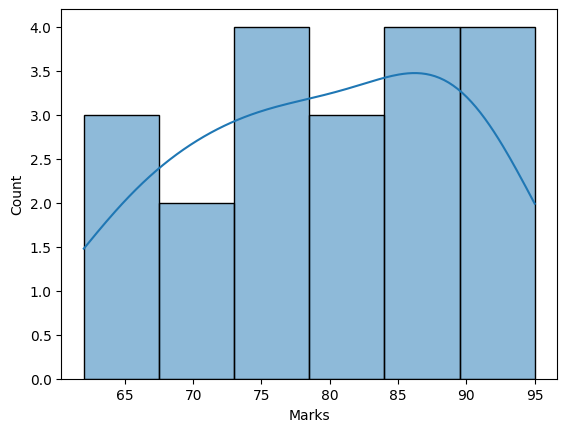

In [12]:
sns.histplot(ds["Marks"], kde= True)
plt.show()

In [13]:
from math import log2

yes = 10
no = 10
total = yes + no

p_yes = yes / total
p_no = no / total

entropy = -(
    p_yes * log2(p_yes) +
    p_no * log2(p_no)
)

print("P(Yes):", p_yes)
print("P(No):", p_no)
print("Entropy:", entropy)

P(Yes): 0.5
P(No): 0.5
Entropy: 1.0


In [17]:
ds["Course"].value_counts()

,count
Course,
MCA,11
BCA,9


In [18]:
for course in ds["Course"].unique():
    subset = ds[ds["Course"] == course]

    counts = subset["Placed"].value_counts()
    total = len(subset)

    entropy = 0

    for count in counts:
        p = count / total
        entropy -= p * log2(p)

    print(course, "Entropy =", entropy)

MCA Entropy = 0.4394969869215134
BCA Entropy = 0.0


In [20]:
pd.crosstab(ds["Course"], ds["Placed"])

Placed,No,Yes
Course,,
BCA,9,0
MCA,1,10


In [21]:
ds[["Marks", "Placed"]].sort_values("Marks")

,Marks,Placed
6,62,No
17,64,No
2,67,No
13,68,No
8,71,No
15,73,No
4,74,No
11,76,No
0,78,No
19,79,No
